# Perceptron Mistake Bound (Block-Novikoff Theorem)

## Learning Objectives
- State the **Block-Novikoff theorem (1962)**: the perceptron makes at most $(D/\gamma)^2$ mistakes
- Understand the two quantities: $D$ (radius of data) and $\gamma$ (margin of the best separator)
- Follow the two-inequality proof: lower bound on $\theta^T u$ and upper bound on $\|\theta\|^2$
- See that the bound is **independent of dimension $n$ and sequence length $m$** — a remarkable property
- Connect the mistake bound to the SVM margin: a larger margin means fewer perceptron mistakes

## Problem Statement

**Setup:** Examples $(x^{(1)}, y^{(1)}), \ldots, (x^{(m)}, y^{(m)})$ with $y^{(i)} \in \{-1, +1\}$.

Define two constants:
- $D = \max_i \|x^{(i)}\|$ — radius: how far the data points are from the origin
- $\gamma$ — margin of the best separator: there exists a unit vector $u$ ($\|u\|_2 = 1$) such that $y^{(i)}(u^T x^{(i)}) \geq \gamma$ for all $i$

**Theorem (Block 1962, Novikoff 1962).** The total number of mistakes the perceptron makes is at most:
$$k \leq \left(\frac{D}{\gamma}\right)^2$$

**Key facts:**
- No dependence on $n$ (dimension) or $m$ (sequence length)
- Bound is tight — there exist sequences where the perceptron makes exactly $(D/\gamma)^2$ mistakes
- Smaller margin $\gamma$ → more mistakes; larger data radius $D$ → more mistakes

## 1. Proof: Two Inequalities

Let $\theta^{(k)}$ be the weights when the $k$-th mistake is made. We start with $\theta^{(1)} = \vec{0}$.

After the $k$-th mistake the update fires: $\theta^{(k+1)} = \theta^{(k)} + y^{(i)} x^{(i)}$.

---

**Inequality 1 — Lower bound on $(\theta^{(k+1)})^T u$:**
$$( \theta^{(k+1)})^T u = (\theta^{(k)})^T u + y^{(i)} (x^{(i)})^T u \geq (\theta^{(k)})^T u + \gamma$$

By induction: $(\theta^{(k+1)})^T u \geq k\gamma$

---

**Inequality 2 — Upper bound on $\|\theta^{(k+1)}\|^2$:**

On a mistake, $(x^{(i)})^T \theta^{(k)} y^{(i)} \leq 0$, so:
$$\|\theta^{(k+1)}\|^2 = \|\theta^{(k)} + y^{(i)} x^{(i)}\|^2 = \|\theta^{(k)}\|^2 + \|x^{(i)}\|^2 + 2 y^{(i)} (x^{(i)})^T \theta^{(k)} \leq \|\theta^{(k)}\|^2 + D^2$$

By induction: $\|\theta^{(k+1)}\|^2 \leq k D^2$

---

**Combining:** Since $u$ is a unit vector, $(\theta^{(k+1)})^T u \leq \|\theta^{(k+1)}\|$:
$$k\gamma \leq (\theta^{(k+1)})^T u \leq \|\theta^{(k+1)}\| \leq \sqrt{k} D$$
$$k\gamma \leq \sqrt{k} D \implies \sqrt{k} \leq \frac{D}{\gamma} \implies k \leq \left(\frac{D}{\gamma}\right)^2 \qquad \blacksquare$$

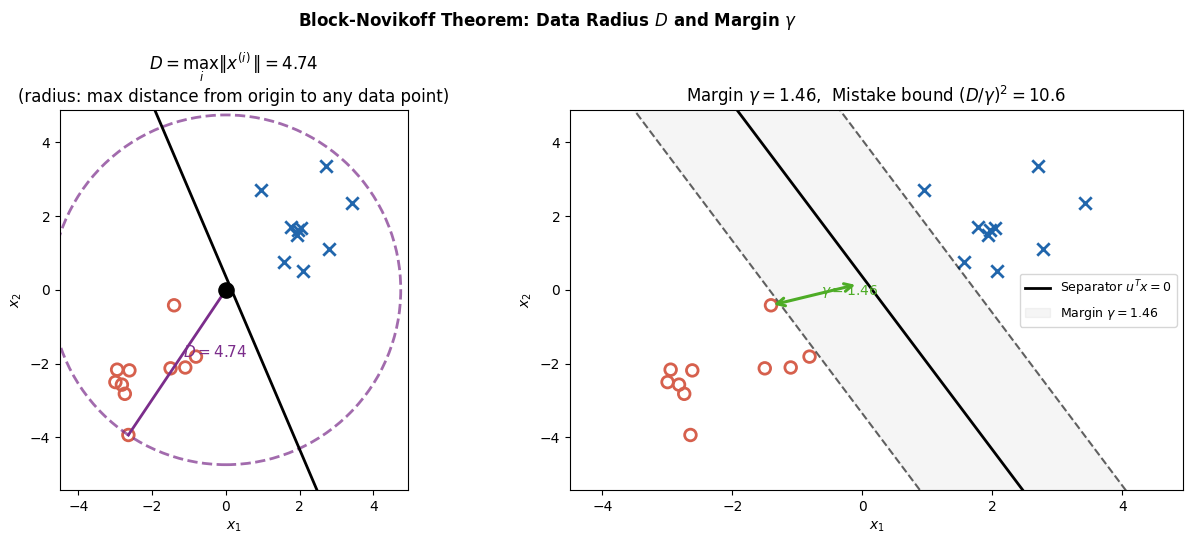

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualise the two key quantities D and gamma on a dataset
np.random.seed(3)
from sklearn.svm import SVC

X_pos = np.random.randn(10, 2) * 0.8 + [2, 2]
X_neg = np.random.randn(10, 2) * 0.8 + [-2, -2]
X     = np.vstack([X_pos, X_neg])
y_pm  = np.array([1]*10 + [-1]*10)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y_pm)
w   = clf.coef_[0]
b   = clf.intercept_[0]
u   = w / np.linalg.norm(w)       # unit normal = optimal separator direction

D     = np.max(np.linalg.norm(X, axis=1))
gamma = np.min(y_pm * (X @ u))    # min signed margin
bound = (D / gamma) ** 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

xmin, xmax = X[:,0].min()-1.5, X[:,0].max()+1.5
ymin, ymax = X[:,1].min()-1.5, X[:,1].max()+1.5
x_line = np.linspace(xmin, xmax, 300)

# Left: show D (radius) — distance from origin to each point
ax = axes[0]
y_db = -(w[0]*x_line + b) / w[1]
ax.plot(x_line, y_db, 'k-', lw=2)
ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', c='#2166ac', s=80, lw=2)
ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70, facecolors='none',
           edgecolors='#d6604d', lw=2)

# Draw radius D from origin to farthest point
farthest = X[np.argmax(np.linalg.norm(X, axis=1))]
circle = plt.Circle((0, 0), D, fill=False, color='#7b2d8b', lw=2, ls='--', alpha=0.7)
ax.add_patch(circle)
ax.plot([0, farthest[0]], [0, farthest[1]], '#7b2d8b', lw=2)
ax.scatter(0, 0, s=120, c='k', zorder=6)
mid = farthest / 2
ax.text(mid[0]+0.15, mid[1]+0.15, f'$D={D:.2f}$', fontsize=11, color='#7b2d8b', fontweight='bold')

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'$D = \\max_i \\|x^{{(i)}}\\| = {D:.2f}$\n(radius: max distance from origin to any data point)')
ax.set_aspect('equal', adjustable='box')

# Right: show gamma (margin)
ax = axes[1]
y_mp = -(w[0]*x_line + b - gamma*np.linalg.norm(w)) / w[1]
y_mn = -(w[0]*x_line + b + gamma*np.linalg.norm(w)) / w[1]
ax.plot(x_line, y_db, 'k-', lw=2, label='Separator $u^T x = 0$')
ax.plot(x_line, y_mp, 'k--', lw=1.5, alpha=0.6)
ax.plot(x_line, y_mn, 'k--', lw=1.5, alpha=0.6)
ax.fill_between(x_line, y_mn, y_mp, alpha=0.08, color='gray', label=f'Margin $\\gamma={gamma:.2f}$')

ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', c='#2166ac', s=80, lw=2)
ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70, facecolors='none',
           edgecolors='#d6604d', lw=2)

# Draw gamma arrow on closest point
closest_idx = np.argmin(y_pm * (X @ u))
pt  = X[closest_idx]
foot = pt - (u @ pt) * u
ax.annotate('', xy=foot, xytext=pt,
            arrowprops=dict(arrowstyle='<->', color='#4dac26', lw=2.2, mutation_scale=14))
ax.text((pt[0]+foot[0])/2 + 0.1, (pt[1]+foot[1])/2,
        f'$\\gamma={gamma:.2f}$', fontsize=10, color='#4dac26', fontweight='bold')

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'Margin $\\gamma = {gamma:.2f}$,  Mistake bound $(D/\\gamma)^2 = {bound:.1f}$')
ax.legend(fontsize=9)

fig.suptitle('Block-Novikoff Theorem: Data Radius $D$ and Margin $\\gamma$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Empirical Verification of the Bound

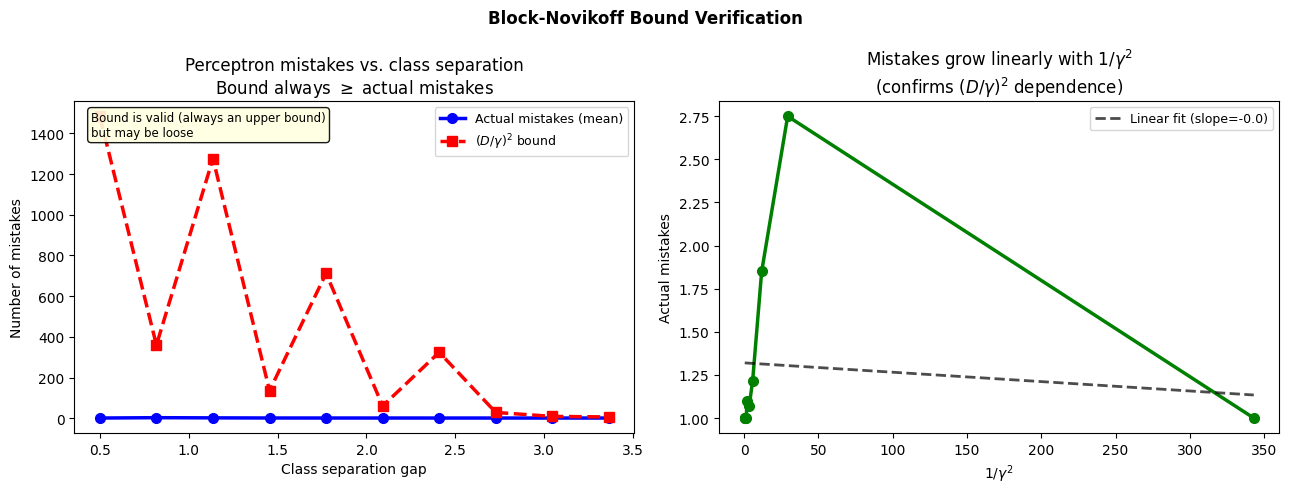

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

def perceptron_train(X, y, max_passes=100):
    theta = np.zeros(X.shape[1])
    mistakes = 0
    for _ in range(max_passes):
        errors = 0
        for i in range(len(X)):
            pred = 1 if theta @ X[i] >= 0 else -1
            if pred != y[i]:
                theta += y[i] * X[i]
                mistakes += 1
                errors += 1
        if errors == 0:
            break
    return theta, mistakes

np.random.seed(0)

# Vary the margin by pushing classes closer/farther apart
n_trials  = 30
gap_values = np.linspace(0.5, 4.0, 12)   # distance between class centres

actual_mistakes = []
theoretical_bounds = []
empirical_gammas   = []

for gap in gap_values:
    trial_mistakes = []
    trial_bounds   = []
    trial_gammas   = []
    for _ in range(n_trials):
        X_p = np.random.randn(15, 2) * 0.6 + [gap/2,  gap/2]
        X_n = np.random.randn(15, 2) * 0.6 + [-gap/2, -gap/2]
        Xd  = np.vstack([X_p, X_n])
        yd  = np.array([1]*15 + [-1]*15)

        # Compute D and gamma via SVM
        D_val = np.max(np.linalg.norm(Xd, axis=1))
        clf   = SVC(kernel='linear', C=1e6)
        clf.fit(Xd, yd)
        u_opt = clf.coef_[0] / np.linalg.norm(clf.coef_[0])
        gamma_val = np.min(yd * (Xd @ u_opt))

        if gamma_val <= 0:
            continue

        _, k = perceptron_train(Xd, yd)
        trial_mistakes.append(k)
        trial_bounds.append((D_val / gamma_val) ** 2)
        trial_gammas.append(gamma_val)

    if trial_mistakes:
        actual_mistakes.append(np.mean(trial_mistakes))
        theoretical_bounds.append(np.mean(trial_bounds))
        empirical_gammas.append(np.mean(trial_gammas))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: actual mistakes vs. theoretical bound vs. margin
ax = axes[0]
ax.plot(gap_values[:len(actual_mistakes)], actual_mistakes,    'b-o', lw=2.5, ms=7,
        label='Actual mistakes (mean)')
ax.plot(gap_values[:len(actual_mistakes)], theoretical_bounds, 'r--s', lw=2.5, ms=7,
        label='$(D/\\gamma)^2$ bound')
ax.set_xlabel('Class separation gap')
ax.set_ylabel('Number of mistakes')
ax.set_title('Perceptron mistakes vs. class separation\nBound always $\\geq$ actual mistakes')
ax.legend(fontsize=9)
ax.text(0.03, 0.97,
        'Bound is valid (always an upper bound)\nbut may be loose',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Right: actual mistakes vs. 1/gamma^2 — shows the 1/gamma^2 dependence
ax = axes[1]
inv_gamma2 = [1/g**2 for g in empirical_gammas]
ax.plot(inv_gamma2, actual_mistakes, 'g-o', lw=2.5, ms=7)
# Fit a line
coeffs = np.polyfit(inv_gamma2, actual_mistakes, 1)
xfit = np.linspace(min(inv_gamma2), max(inv_gamma2), 100)
ax.plot(xfit, np.polyval(coeffs, xfit), 'k--', lw=2, alpha=0.7,
        label=f'Linear fit (slope={coeffs[0]:.1f})')
ax.set_xlabel('$1/\\gamma^2$')
ax.set_ylabel('Actual mistakes')
ax.set_title('Mistakes grow linearly with $1/\\gamma^2$\n(confirms $(D/\\gamma)^2$ dependence)')
ax.legend(fontsize=9)

fig.suptitle('Block-Novikoff Bound Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. The Proof Inequalities Visualised

The proof uses two quantities that evolve as the perceptron makes mistakes:

| Quantity | After $k$ mistakes | Key step |
|---|---|---|
| $(\theta^{(k+1)})^T u$ | $\geq k\gamma$ | Grows **at least linearly** in $k$ |
| $\|\theta^{(k+1)}\|^2$ | $\leq k D^2$ | Grows **at most linearly** in $k$ |

Since $z^T u \leq \|z\| \cdot \|u\| = \|z\|$ for any unit $u$:
$$k\gamma \leq \|\theta^{(k+1)}\| \leq \sqrt{kD^2} = \sqrt{k}\,D \implies k \leq (D/\gamma)^2$$

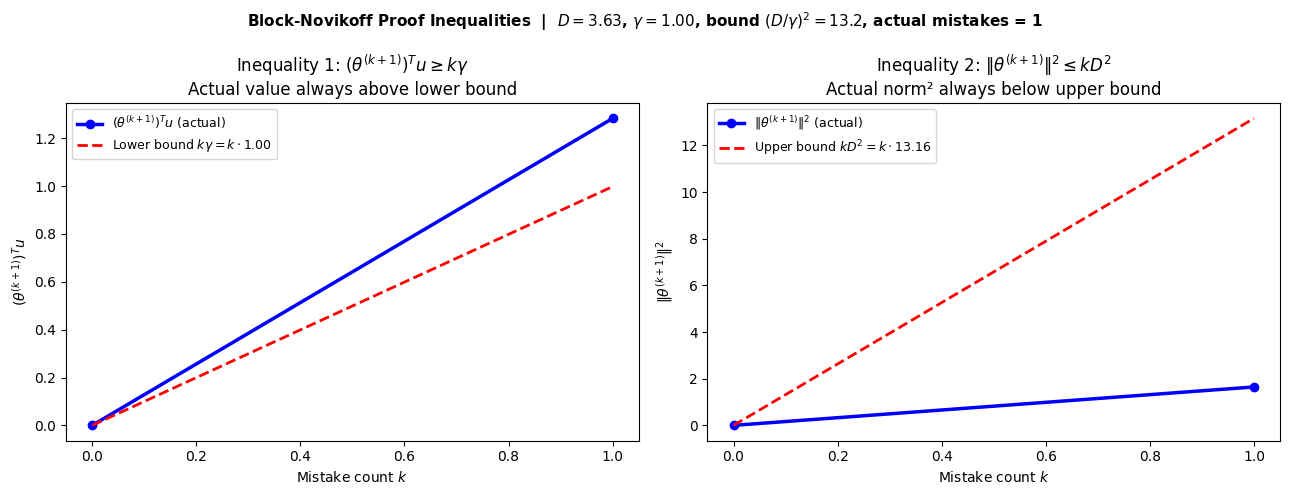

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(5)

X_pos = np.random.randn(12, 2) * 0.7 + [1.5, 1.5]
X_neg = np.random.randn(12, 2) * 0.7 + [-1.5, -1.5]
X     = np.vstack([X_pos, X_neg])
y_pm  = np.array([1]*12 + [-1]*12)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y_pm)
u   = clf.coef_[0] / np.linalg.norm(clf.coef_[0])
D   = np.max(np.linalg.norm(X, axis=1))
gamma = np.min(y_pm * (X @ u))

# Collect theta at each mistake
theta = np.zeros(2)
dot_u_vals = [0.0]
norm2_vals = [0.0]
k_vals     = [0]
k = 0

for _ in range(50):
    changed = False
    for i in range(len(X)):
        pred = 1 if theta @ X[i] >= 0 else -1
        if pred != y_pm[i]:
            theta += y_pm[i] * X[i]
            k += 1
            dot_u_vals.append(float(theta @ u))
            norm2_vals.append(float(theta @ theta))
            k_vals.append(k)
            changed = True
    if not changed:
        break

k_arr = np.array(k_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: lower bound on (theta^T u)
ax = axes[0]
ax.plot(k_arr, dot_u_vals, 'b-o', lw=2.5, ms=6, label='$(\\theta^{(k+1)})^T u$ (actual)')
ax.plot(k_arr, k_arr * gamma, 'r--', lw=2, label=f'Lower bound $k\\gamma = k \\cdot {gamma:.2f}$')
ax.set_xlabel('Mistake count $k$')
ax.set_ylabel('$(\\theta^{(k+1)})^T u$')
ax.set_title('Inequality 1: $(\\theta^{(k+1)})^T u \\geq k\\gamma$\nActual value always above lower bound')
ax.legend(fontsize=9)

# Right: upper bound on ||theta||^2
ax = axes[1]
ax.plot(k_arr, norm2_vals,      'b-o', lw=2.5, ms=6, label='$\\|\\theta^{(k+1)}\\|^2$ (actual)')
ax.plot(k_arr, k_arr * D**2,    'r--', lw=2, label=f'Upper bound $kD^2 = k \\cdot {D**2:.2f}$')
ax.set_xlabel('Mistake count $k$')
ax.set_ylabel('$\\|\\theta^{(k+1)}\\|^2$')
ax.set_title('Inequality 2: $\\|\\theta^{(k+1)}\\|^2 \\leq kD^2$\nActual norm² always below upper bound')
ax.legend(fontsize=9)

bound = (D / gamma) ** 2
fig.suptitle(f'Block-Novikoff Proof Inequalities  |  $D={D:.2f}$, $\\gamma={gamma:.2f}$, '
             f'bound $(D/\\gamma)^2 = {bound:.1f}$, actual mistakes = {k}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Connection to SVM: Margin as the Key Quantity

The mistake bound $(D/\gamma)^2$ makes the connection to SVMs explicit:

| Quantity | Perceptron view | SVM view |
|---|---|---|
| $\gamma$ | Margin of any linear separator $u$ | Maximised by the SVM solution |
| $(D/\gamma)^2$ | Upper bound on perceptron mistakes | Smaller → fewer mistakes, better generalisation |
| Maximising $\gamma$ | Minimises the mistake bound | Exactly the SVM objective |

The SVM can be thought of as finding the separator $u$ that **minimises the perceptron mistake bound** $(D/\gamma)^2$ over all possible linear classifiers.

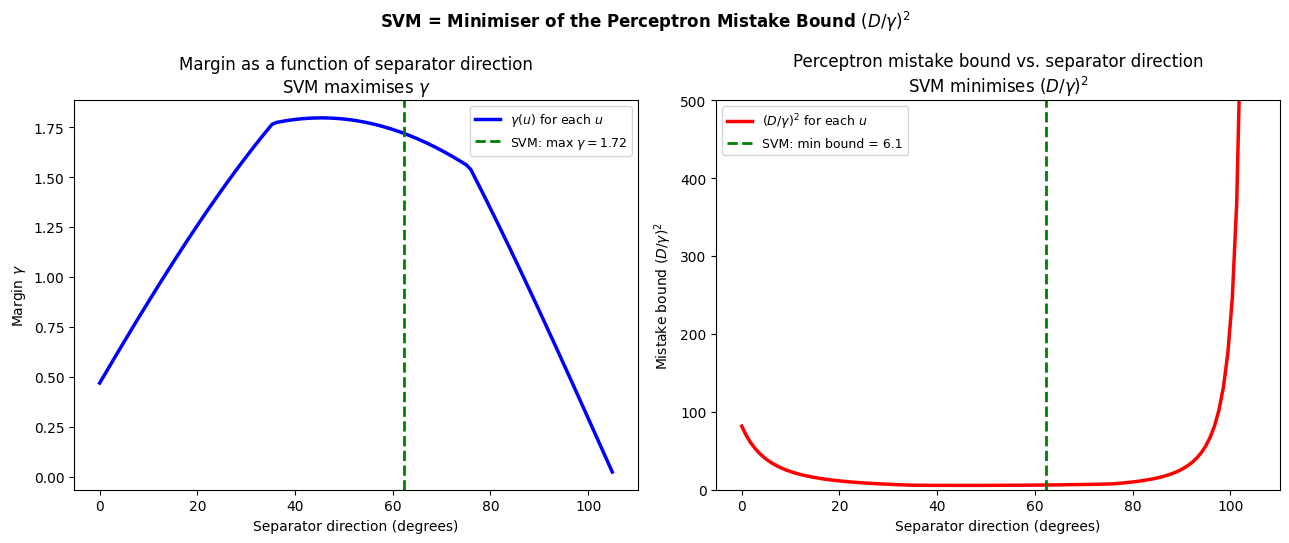

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(0)

# Show how the mistake bound (D/gamma)^2 changes for random linear separators
# vs the SVM separator (which maximises gamma)

X_pos = np.random.randn(15, 2) * 0.6 + [2, 2]
X_neg = np.random.randn(15, 2) * 0.6 + [-2, -2]
X     = np.vstack([X_pos, X_neg])
y_pm  = np.array([1]*15 + [-1]*15)
D     = np.max(np.linalg.norm(X, axis=1))

# SVM separator
clf   = SVC(kernel='linear', C=1e6)
clf.fit(X, y_pm)
u_svm = clf.coef_[0] / np.linalg.norm(clf.coef_[0])
gamma_svm = np.min(y_pm * (X @ u_svm))
bound_svm = (D / gamma_svm) ** 2

# Random valid separators
angles = np.linspace(0, np.pi, 200)
gammas, bounds = [], []
for angle in angles:
    u = np.array([np.cos(angle), np.sin(angle)])
    g = np.min(y_pm * (X @ u))
    if g > 0:
        gammas.append(g)
        bounds.append((D / g) ** 2)
    else:
        gammas.append(np.nan)
        bounds.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: gamma vs. separator angle
ax = axes[0]
ax.plot(np.degrees(angles), gammas, 'b-', lw=2.5, label='$\\gamma(u)$ for each $u$')
svm_angle = np.degrees(np.arctan2(u_svm[1], u_svm[0]))
ax.axvline(svm_angle % 180, color='green', ls='--', lw=2,
           label=f'SVM: max $\\gamma = {gamma_svm:.2f}$')
ax.set_xlabel('Separator direction (degrees)')
ax.set_ylabel('Margin $\\gamma$')
ax.set_title('Margin as a function of separator direction\nSVM maximises $\\gamma$')
ax.legend(fontsize=9)

# Right: mistake bound vs. separator angle
ax = axes[1]
ax.plot(np.degrees(angles), bounds, 'r-', lw=2.5, label='$(D/\\gamma)^2$ for each $u$')
ax.axvline(svm_angle % 180, color='green', ls='--', lw=2,
           label=f'SVM: min bound = {bound_svm:.1f}')
ax.set_xlabel('Separator direction (degrees)')
ax.set_ylabel('Mistake bound $(D/\\gamma)^2$')
ax.set_title('Perceptron mistake bound vs. separator direction\nSVM minimises $(D/\\gamma)^2$')
ax.legend(fontsize=9)
ax.set_ylim(0, min(500, np.nanmax(bounds) * 1.1))

fig.suptitle('SVM = Minimiser of the Perceptron Mistake Bound $(D/\\gamma)^2$',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Derivation Pathway

### Derivation pathway

In [5]:
from IPython.display import HTML
HTML("""
<svg xmlns="http://www.w3.org/2000/svg" width="780" height="374"
     viewBox="0 0 780 374" font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="ah" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#444"/>
    </marker>
    <marker id="ahd" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#999"/>
    </marker>
  </defs>

  <!-- Row 1: Data + margin -->
  <rect x="10" y="12" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="35" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Data: radius D</text>
  <text x="102" y="52" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">margin &#x3b3;</text>
  <line x1="197" y1="35" x2="216" y2="35"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="12" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="40" font-size="13" text-anchor="middle" fill="#333"
        >D = max||x&#x2071;||; &#x3b3; = min y&#x2071;(u&#x1d40;x&#x2071;) for best unit separator u</text>

  <!-- step 1&#x2192;2 -->
  <line x1="102" y1="58" x2="102" y2="108"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="82" font-size="11.5" font-style="italic" fill="#555"
        >run perceptron, track &#x3b8;&#x207f; after each mistake</text>

  <!-- Row 2: Two inequalities -->
  <rect x="10" y="112" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="135" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Two inductive</text>
  <text x="102" y="152" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">inequalities</text>
  <line x1="197" y1="135" x2="216" y2="135"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="112" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="140" font-size="13" text-anchor="middle" fill="#333"
        >(&#x3b8;&#x207f;)&#x1d40;u &#x2265; k&#x3b3;  AND  ||&#x3b8;&#x207f;||&#xb2; &#x2264; kD&#xb2; (proved by induction on mistakes)</text>

  <!-- step 2&#x2192;3 -->
  <line x1="102" y1="158" x2="102" y2="208"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="182" font-size="11.5" font-style="italic" fill="#555"
        >combine: k&#x3b3; &#x2264; ||&#x3b8;&#x207f;|| &#x2264; &#x221a;k &#xb7; D</text>

  <!-- Row 3: Combined bound -->
  <rect x="10" y="212" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="240" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">k&#x3b3; &#x2264; &#x221a;k D</text>
  <line x1="197" y1="235" x2="216" y2="235"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="212" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="240" font-size="13" text-anchor="middle" fill="#333"
        >uses Cauchy-Schwarz: (&#x3b8;&#x207f;)&#x1d40;u &#x2264; ||&#x3b8;&#x207f;|| ||u|| = ||&#x3b8;&#x207f;||</text>

  <!-- step 3&#x2192;4 -->
  <line x1="102" y1="258" x2="102" y2="308"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="282" font-size="11.5" font-style="italic" fill="#555"
        >divide both sides by &#x221a;k &#xb7; &#x3b3;</text>

  <!-- Row 4: Bound -->
  <rect x="10" y="312" width="185" height="46" rx="7"
        fill="#1a5fa8" stroke="#1a5fa8" stroke-width="2"/>
  <text x="102" y="340" font-size="13.5" font-weight="700"
        text-anchor="middle" fill="#ffffff">k &#x2264; (D/&#x3b3;)&#xb2;</text>
  <line x1="197" y1="335" x2="216" y2="335"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="312" width="548" height="46" rx="7"
        fill="#dce8f8" stroke="#7aadd4" stroke-width="1.5"/>
  <text x="495" y="340" font-size="13" text-anchor="middle" fill="#333"
        >independent of dimension n and sequence length m &#x2014; depends only on D and &#x3b3;</text>
</svg>
""")

## Summary

| Concept | Formula | Key Insight |
|---|---|---|
| Data radius | $D = \max_i \|x^{(i)}\|$ | Distance from origin to farthest point |
| Margin | $\gamma = \min_i y^{(i)}(u^T x^{(i)})$ | Confidence of the best unit separator |
| Mistake bound | $k \leq (D/\gamma)^2$ | Block-Novikoff (1962); dimension-free |
| Lower bound (proof) | $(\theta^{(k+1)})^T u \geq k\gamma$ | Alignment with $u$ grows linearly |
| Upper bound (proof) | $\|\theta^{(k+1)}\|^2 \leq kD^2$ | Norm grows at most linearly |
| SVM connection | SVM maximises $\gamma$ | SVM minimises the perceptron mistake bound |

**Key insight:** the perceptron mistake bound $(D/\gamma)^2$ is independent of both the input dimension $n$ and the sequence length $m$ — it depends only on the geometry of the data; larger margin $\gamma$ means fewer mistakes, which is exactly why SVM's maximum-margin criterion is well-motivated.